Decision Tree classifier, ROC

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

In [2]:
f = h5py.File('sample_2e7_design_precessing_higherordermodes_3detectors.h5')
f.keys()

<KeysViewHDF5 ['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'det', 'iota', 'mtot', 'psi', 'q', 'ra', 'snr', 'z']>

In [3]:
data = np.array([f[x] for x in ['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'det', 'iota', 'mtot', 'psi', 'q', 'ra', 'snr', 'z']])

In [4]:
print(len(data[14]))          #it's 15 elements, each contain 20000000 elements
data = data.T

20000000


In [5]:
np.random.shuffle(data)
tot = 200000                      #20000000
train = 150000                    #works bot as validation and as downsampling
validation = tot - train
data_train = data[:train]
data_validation = data[-validation:]

In [6]:
x_train = np.delete(data_train, [7, 13], 1)     #ho perso 1 ora perchè non toglievo la colonna 13 (snr) e mi dava completeness 1 e contamination 0 con depth 1
y_train = data_train[:,7]
x_validation = np.delete(data_validation, [7, 13], 1)
y_validation = data_validation[:,7]

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve

In [8]:
x_train = np.nan_to_num(x_train)        #clf.fit was having problems

In [9]:
clf = DecisionTreeClassifier()
drange = np.arange(1, 20)  #Complete

grid = GridSearchCV(clf, param_grid={'max_depth': drange}, cv=5)
grid.fit(x_train, y_train)

best = grid.best_params_['max_depth']
print("best parameter choice:", best)

best parameter choice: 9


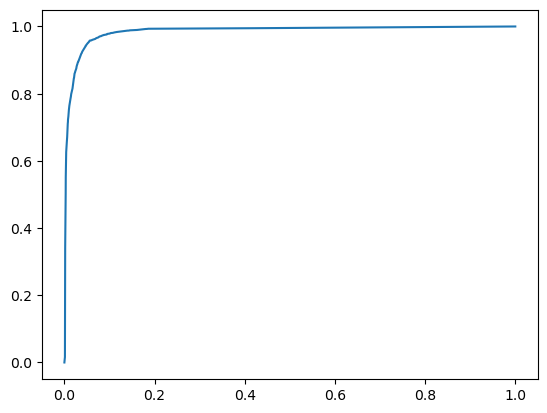

In [10]:
clf = DecisionTreeClassifier(random_state=0, max_depth=best, criterion='gini')      #I tried both gini and entropy
clf.fit(x_train, y_train)
y_pred = clf.predict_proba(x_validation)[:,1]

fpr, tpr, thresh = roc_curve(y_validation, y_pred)
plt.plot(fpr, tpr)

In [11]:
from astroML.utils import completeness_contamination

In [12]:
completeness, contamination = completeness_contamination(y_pred, y_validation)

print("completeness", completeness)
print("contamination", contamination)
#gives me low completeness and 1 contamination
#but everything else works
#it gives me 0 and 1 because I used predict proba, which doesn't "collapse" the result to the classes

completeness 0.016246498599439777
contamination 0.9934908254306717


In [13]:
comp_train = []
cont_train = []
comp_validation = []
cont_validation = []


for i in drange:
    clf = DecisionTreeClassifier(random_state=0, max_depth=i, criterion='gini')
    clf.fit(x_train, y_train)

    y_pred = clf.predict(x_train)
    completeness_train, contamination_train = completeness_contamination(y_pred, y_train)

    y_pred = clf.predict(x_validation)
    completeness_validation, contamination_validation = completeness_contamination(y_pred, y_validation)

    comp_train.append(completeness_train)
    cont_train.append(contamination_train)

    comp_validation.append(completeness_validation)
    cont_validation.append(contamination_validation)

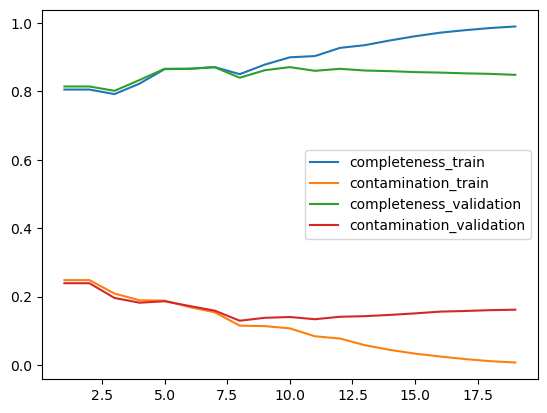

In [14]:
plt.plot(drange, comp_train, label="completeness_train")
plt.plot(drange, cont_train, label="contamination_train")
plt.plot(drange, comp_validation, label="completeness_validation")
plt.plot(drange, cont_validation, label="contamination_validation")
plt.legend()